## Load EMG Data

In [ ]:
import pandas as pd
import numpy as np

# emg.csv:
# timestamp,emg_channel_1,emg_channel_2,emg_channel_3,emg_channel_4,emg_channel_5,emg_channel_6,emg_channel_7,emg_channel_8

# finger_angles.csv:
# timestamp,THUMB,INDEX,MIDDLE,RING,PINKY

# Load EMG data and finger angle data
emg_data = pd.read_csv("../data/EMG Hand Data 20241030_223524/emg.csv")
finger_angles = pd.read_csv("../data/EMG Hand Data 20241030_223524/finger_angles.csv")

# Rectify EMG data (absolute value for each EMG channel)
emg_channels = emg_data.columns[1:]  # EMG channel columns (excluding 'timestamp')
rectified_emg_data = emg_data.copy()
rectified_emg_data[emg_channels] = emg_data[emg_channels].abs()

# Normalize rectified EMG data using Z-score normalization
def normalize_emg(data):
    return (data - data.mean()) / data.std()

normalized_emg_data = rectified_emg_data.copy()
normalized_emg_data[emg_channels] = rectified_emg_data[emg_channels].apply(normalize_emg)

# Confirm normalization: check mean ~0 and std ~1 for each channel
means = normalized_emg_data[emg_channels].mean()
stds = normalized_emg_data[emg_channels].std()

# Assert that means and std are close to 0 and 1, respectively
assert np.allclose(means, 0, atol=0.1), f"Means not close to 0: {means}"
assert np.allclose(stds, 1, atol=0.1), f"Standard deviations not close to 1: {stds}"

# Assert that rectified data is non-negative
assert (rectified_emg_data[emg_channels] >= 0).all().all(), "Rectification failed; found negative values."

In [154]:
joint_angle_thresholds = {
    'thumb': (132.5, 157.5),
    'index': (60, 160),
    'middle': (40, 167.5),
    'ring': (30, 167.5),
    'pinky': (30, 167.5)
}

def normalize_finger_angle(data, joint):
    normalized_data = (data - joint_angle_thresholds[joint][0]) / (joint_angle_thresholds[joint][1] - joint_angle_thresholds[joint][0])
    return np.clip(normalized_data, 0, 1)

# Normalize finger angle data
finger_angles_normalized = finger_angles.copy()
finger_angles_normalized['THUMB'] = normalize_finger_angle(finger_angles['THUMB'], 'thumb')
finger_angles_normalized['INDEX'] = normalize_finger_angle(finger_angles['INDEX'], 'index')
finger_angles_normalized['MIDDLE'] = normalize_finger_angle(finger_angles['MIDDLE'], 'middle')
finger_angles_normalized['RING'] = normalize_finger_angle(finger_angles['RING'], 'ring')
finger_angles_normalized['PINKY'] = normalize_finger_angle(finger_angles['PINKY'], 'pinky')

finger_angles_normalized.head()

,timestamp,THUMB,INDEX,MIDDLE,RING,PINKY
0,1.385861e+06,1.0,1.0,1.0,1.0,1.0
1,1.385861e+06,1.0,1.0,1.0,1.0,1.0
2,1.385861e+06,1.0,1.0,1.0,1.0,1.0
3,1.385861e+06,1.0,1.0,1.0,1.0,1.0
4,1.385861e+06,1.0,1.0,1.0,1.0,1.0


## Low Pass Filter

Estimated Sampling Frequency (fs): 250 Hz


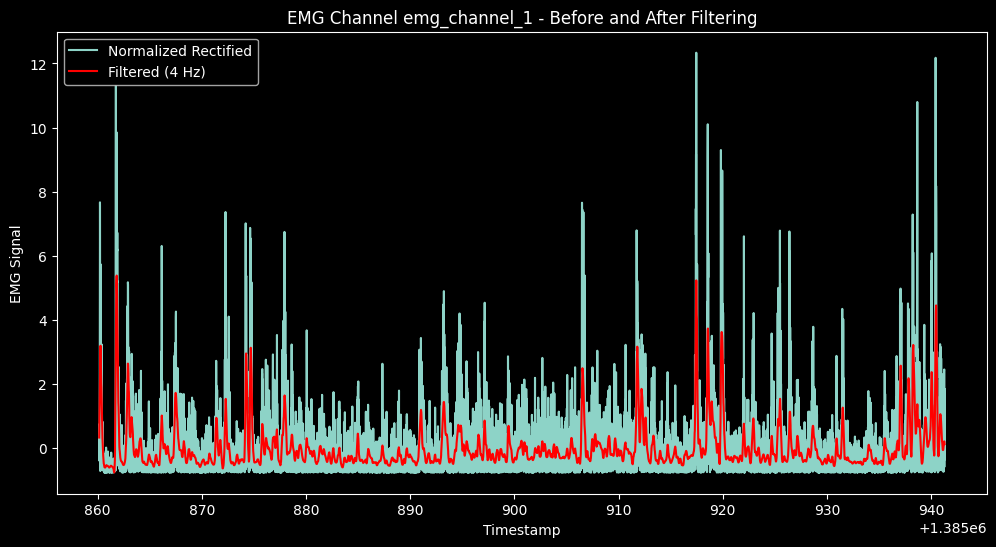

In [ ]:
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

# Define low-pass filter parameters
def low_pass_filter(data, cutoff=4, fs=250, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

def estimate_sampling_frequency(timestamps):
    sampling_intervals = np.diff(timestamps)
    return int(1 / np.mean(sampling_intervals))

# Estimate sampling frequency from EMG data timestamps
emg_fs = estimate_sampling_frequency(normalized_emg_data['timestamp'])
print(f"Estimated Sampling Frequency (fs): {fs} Hz")

# Apply low-pass filter to each EMG channel
filtered_emg_data = normalized_emg_data.copy()
for channel in emg_channels:
    filtered_emg_data[channel] = low_pass_filter(normalized_emg_data[channel], fs=fs)

# Plot sample EMG data before and after filtering for comparison
plt.figure(figsize=(12, 6))
plt.plot(normalized_emg_data['timestamp'], normalized_emg_data[emg_channels[0]], label='Normalized Rectified')
plt.plot(filtered_emg_data['timestamp'], filtered_emg_data[emg_channels[0]], label='Filtered (4 Hz)', color='red')
plt.xlabel('Timestamp')
plt.ylabel('EMG Signal')
plt.title(f'EMG Channel {emg_channels[0]} - Before and After Filtering')
plt.legend()
plt.show()

## Resampling

In [ ]:
from scipy.signal import resample
import numpy as np
import pandas as pd

def resample_dataframe_signal(df, desired_rate, time_column='timestamp'):
    # Ensure the time column is sorted
    df = df.sort_values(by=time_column).reset_index(drop=True)
    
    # Remove rows where all data columns are NaN
    data_columns = df.columns.drop(time_column)
    df = df.dropna(subset=data_columns, how='all').reset_index(drop=True)
    
    time_values = df[time_column].values
    start_time, end_time = time_values[0], time_values[-1]
    num_samples = int((end_time - start_time) * desired_rate)
    new_time_values = np.linspace(start_time, end_time, num=num_samples)
    
    resampled_data = {time_column: new_time_values}
    
    for col in data_columns:
        if df[col].isna().all():
            resampled_data[col] = np.full_like(new_time_values, np.nan, dtype=np.float64)
        else:
            signal = df[col].interpolate(method='linear').values
            resampled_signal = resample(signal, num_samples)
            resampled_data[col] = resampled_signal
    
    return pd.DataFrame(resampled_data)

# Dynamically estimate sampling frequency for finger angle data
finger_fs = estimate_sampling_frequency(finger_angles['timestamp'].values)

# Resample EMG data to match the finger angle data rate
resampled_emg_data = resample_dataframe_signal(filtered_emg_data, desired_rate=finger_fs, time_column='timestamp')
emg_fs = finger_fs
print(f"Resampled EMG Data to {finger_fs} Hz")

Resampled EMG Data to 110 Hz


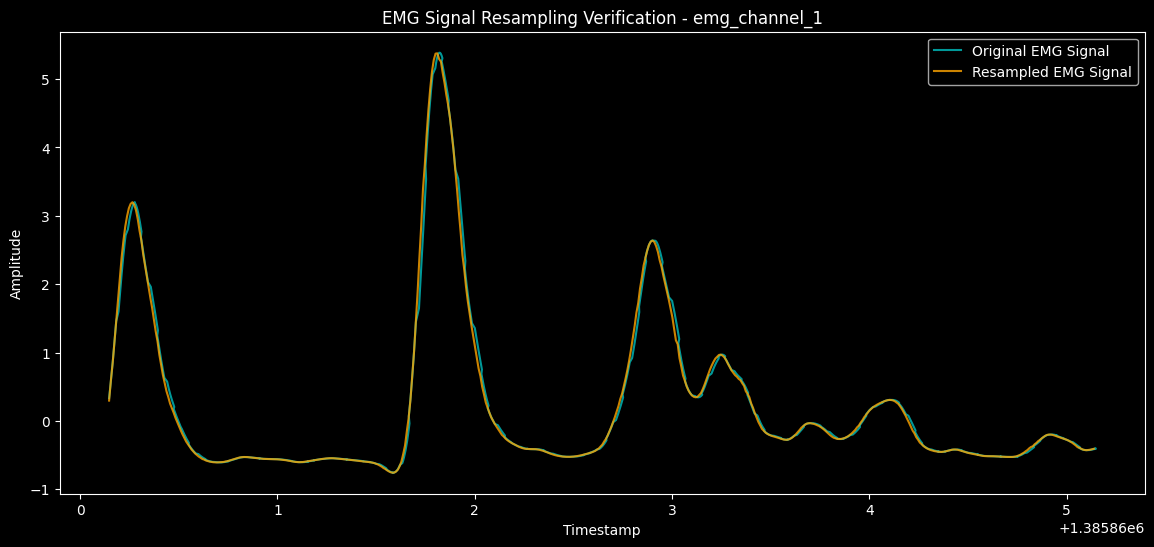

In [ ]:
import matplotlib.pyplot as plt

def visualize_resampling(emg_data, resampled_emg_data, channel, time_column='timestamp', window_duration=5):
    """
    Visualizes the original and resampled EMG signals over a specified time window.

    Parameters:
    - emg_data (pd.DataFrame): Original high-frequency EMG data.
    - resampled_emg_data (pd.DataFrame): Resampled EMG data.
    - channel (str): The name of the EMG channel to plot.
    - time_column (str): The name of the timestamp column.
    - window_duration (int): Duration in seconds for the visualization window.
    """
    # Define the time window for visualization based on the first timestamp and specified duration
    start_time = emg_data[time_column].iloc[0]
    end_time = start_time + window_duration

    # Filter both datasets for the specified time window
    original_time_window = (emg_data[time_column] >= start_time) & (emg_data[time_column] <= end_time)
    resampled_time_window = (resampled_emg_data[time_column] >= start_time) & (resampled_emg_data[time_column] <= end_time)

    # Plot the original and resampled EMG signals using their timestamps
    plt.figure(figsize=(14, 6))

    # Original EMG data (before resampling)
    plt.plot(emg_data.loc[original_time_window, time_column], emg_data.loc[original_time_window, channel], 
             label='Original EMG Signal', color='cyan', alpha=0.6)

    # Resampled EMG data
    plt.plot(resampled_emg_data.loc[resampled_time_window, time_column], resampled_emg_data.loc[resampled_time_window, channel], 
             label='Resampled EMG Signal', color='orange', alpha=0.8)

    # Labels and title
    plt.xlabel('Timestamp')
    plt.ylabel('Amplitude')
    plt.title(f'EMG Signal Resampling Verification - {channel}')
    plt.legend()
    plt.show()

# Example usage:
visualize_resampling(filtered_emg_data, resampled_emg_data, channel=emg_channels[0])

## Muscle Activation

In [210]:
import numpy as np
import matplotlib.pyplot as plt

# Define the muscle activation function with electromechanical delay (EMD)
def muscle_activation(emg_signal, d=45, alpha=0.8, beta1=0.5, beta2=0.5):
    """Applies a second-order recursive filter to model muscle activation.
    
    Parameters:
    - emg_signal: The rectified and normalized EMG signal array.
    - d: Delay parameter (EMD), in samples.
    - alpha, beta1, beta2: Coefficients for the filter.
    
    Returns:
    - activation: The filtered signal representing muscle activation.
    """
    # Initialize the activation array
    activation = np.zeros(len(emg_signal))
    
    # Apply recursive filtering
    for t in range(2, len(emg_signal)):
        if t - d >= 0:
            activation[t] = alpha * emg_signal[t - d] - beta1 * activation[t - 1] - beta2 * activation[t - 2]
    
    return activation

# Select a sample EMG channel for testing the model
sample_channel = emg_channels[0]
sample_emg_signal = resampled_emg_data[sample_channel].values

# Apply the muscle activation model to the selected channel# Experiment with different filter parameters
activated_signal = muscle_activation(sample_emg_signal, d=50, alpha=0.5, beta1=0.3, beta2=0.8)

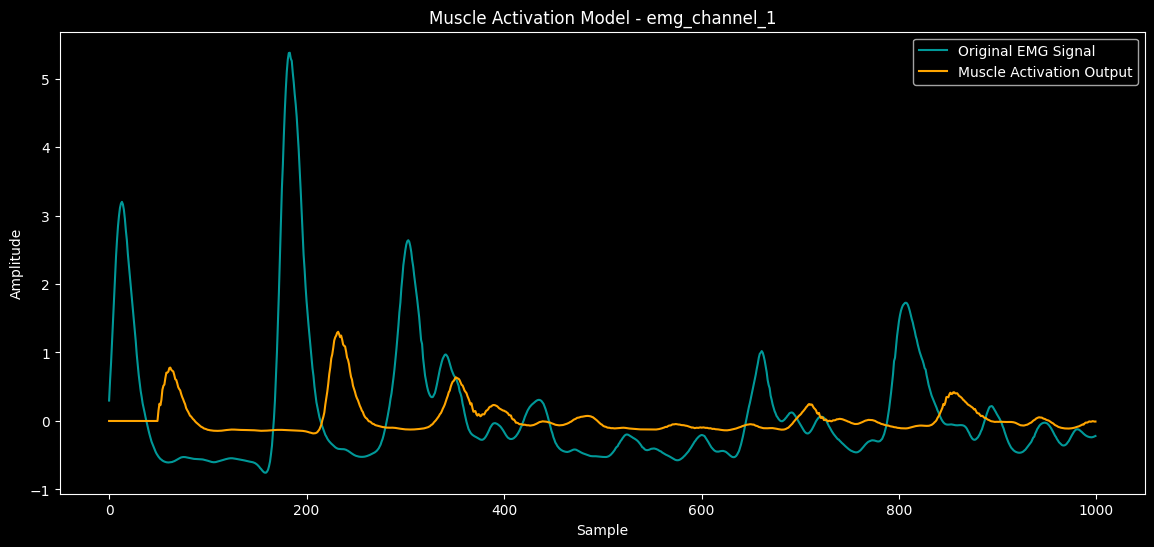

In [211]:
def plot_muscle_activation(original_signal, activated_signal, channel_name, n_samples=1000):
    """Plot the original EMG signal and the muscle activation output for comparison."""
    plt.figure(figsize=(14, 6))
    plt.plot(original_signal[:n_samples], label='Original EMG Signal', color='cyan', alpha=0.6)
    plt.plot(activated_signal[:n_samples], label='Muscle Activation Output', color='orange')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.title(f'Muscle Activation Model - {channel_name}')
    plt.legend()
    plt.show()

# Plot the original and activated signals for visual verification
plot_muscle_activation(sample_emg_signal, activated_signal, sample_channel)

In [212]:
# Create a new DataFrame to store the muscle-activated EMG data
activated_emg_data = resampled_emg_data.copy()

# Apply the muscle activation model to each EMG channel
for channel in emg_channels:
    activated_emg_data[channel] = muscle_activation(resampled_emg_data[channel].values)

# Display the first few rows of the activated EMG data for verification
activated_emg_data.head(10)

,timestamp,emg_channel_1,emg_channel_2,emg_channel_3,emg_channel_4,emg_channel_5,emg_channel_6,emg_channel_7,emg_channel_8
0,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.385860e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [213]:
# Ensure both DataFrames are sorted by timestamp for as-of merging
activated_emg_data_sorted = activated_emg_data.sort_values(by="timestamp").reset_index(drop=True)
finger_angles_sorted = finger_angles_normalized.sort_values(by="timestamp").reset_index(drop=True)

# Perform an as-of merge to align EMG data with the nearest timestamps in finger angles
# `direction='nearest'` aligns each EMG sample to the closest available finger angle sample
aligned_data = pd.merge_asof(activated_emg_data_sorted, finger_angles_sorted, on="timestamp", direction="nearest")

# Separate the aligned EMG data (X) and finger angles (y)
X = aligned_data[emg_channels].values  # Activated EMG data as features
y = aligned_data[['THUMB', 'INDEX', 'MIDDLE', 'RING', 'PINKY']].values  # Finger angle data as targets

# Check the shapes to confirm alignment
print(f"Aligned X shape: {X.shape}, Aligned y shape: {y.shape}")

# Split the data based on timestamp for training and testing
train_val_split= int(len(aligned_data) * 0.8)
val_test_split = int(len(aligned_data) * 0.9)
X_train, y_train = X[:train_val_split], y[:train_val_split]
X_val, y_val = X[train_val_split:val_test_split], y[train_val_split:val_test_split]
X_test, y_test = X[val_test_split:], y[val_test_split:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Aligned X shape: (8926, 8), Aligned y shape: (8926, 5)
X_train shape: (7140, 8), y_train shape: (7140, 5)
X_val shape: (893, 8), y_val shape: (893, 5)
X_test shape: (893, 8), y_test shape: (893, 5)


In [214]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanSquaredError as MSE, RootMeanSquaredError as RMSE
from tensorflow.keras.callbacks import EarlyStopping

# Define the neural network model
model = Sequential([
    Dense(100, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(50, activation='relu'),
    Dense(y_train.shape[1], activation='sigmoid')  # Use sigmoid activation for normalized output
])

# Compile the model
model.compile(optimizer=Adam(), loss=MeanSquaredError(), metrics=[MSE(), RMSE(), 'r2_score'])

# Implement early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_val, y_val), batch_size=1024, callbacks=[early_stopping])

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
test_loss, test_mse, test_rmse, test_r2 = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test MSE: {test_mse}")
print(f"Test RMSE: {test_rmse}")
print(f"Test R^2: {test_r2}")

# Print validation loss and accuracy
val_loss, val_mse, val_rmse, val_r2 = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss}")
print(f"Validation MSE: {val_mse}")
print(f"Validation RMSE: {val_rmse}")
print(f"Validation R^2: {val_r2}")

Epoch 1/200


/Users/sj/Dev/Python/robot-hand/.conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.2158 - mean_squared_error: 0.2158 - r2_score: -0.0569 - root_mean_squared_error: 0.4645 - val_loss: 0.2193 - val_mean_squared_error: 0.2193 - val_r2_score: -0.2753 - val_root_mean_squared_error: 0.4683
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2105 - mean_squared_error: 0.2105 - r2_score: -0.0311 - root_mean_squared_error: 0.4588 - val_loss: 0.2141 - val_mean_squared_error: 0.2141 - val_r2_score: -0.2411 - val_root_mean_squared_error: 0.4628
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2058 - mean_squared_error: 0.2058 - r2_score: -0.0044 - root_mean_squared_error: 0.4536 - val_loss: 0.2094 - val_mean_squared_error: 0.2094 - val_r2_score: -0.2124 - val_root_mean_squared_error: 0.4576
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2016 - mean_squared_error: 0.2016 - r2_score: 0.0196 - root_mean_squared_error: 0.4490 - val_loss: 0.2045 - val_mean_squared_error: 0.2045 - val_r2_score: -0.1823 - v

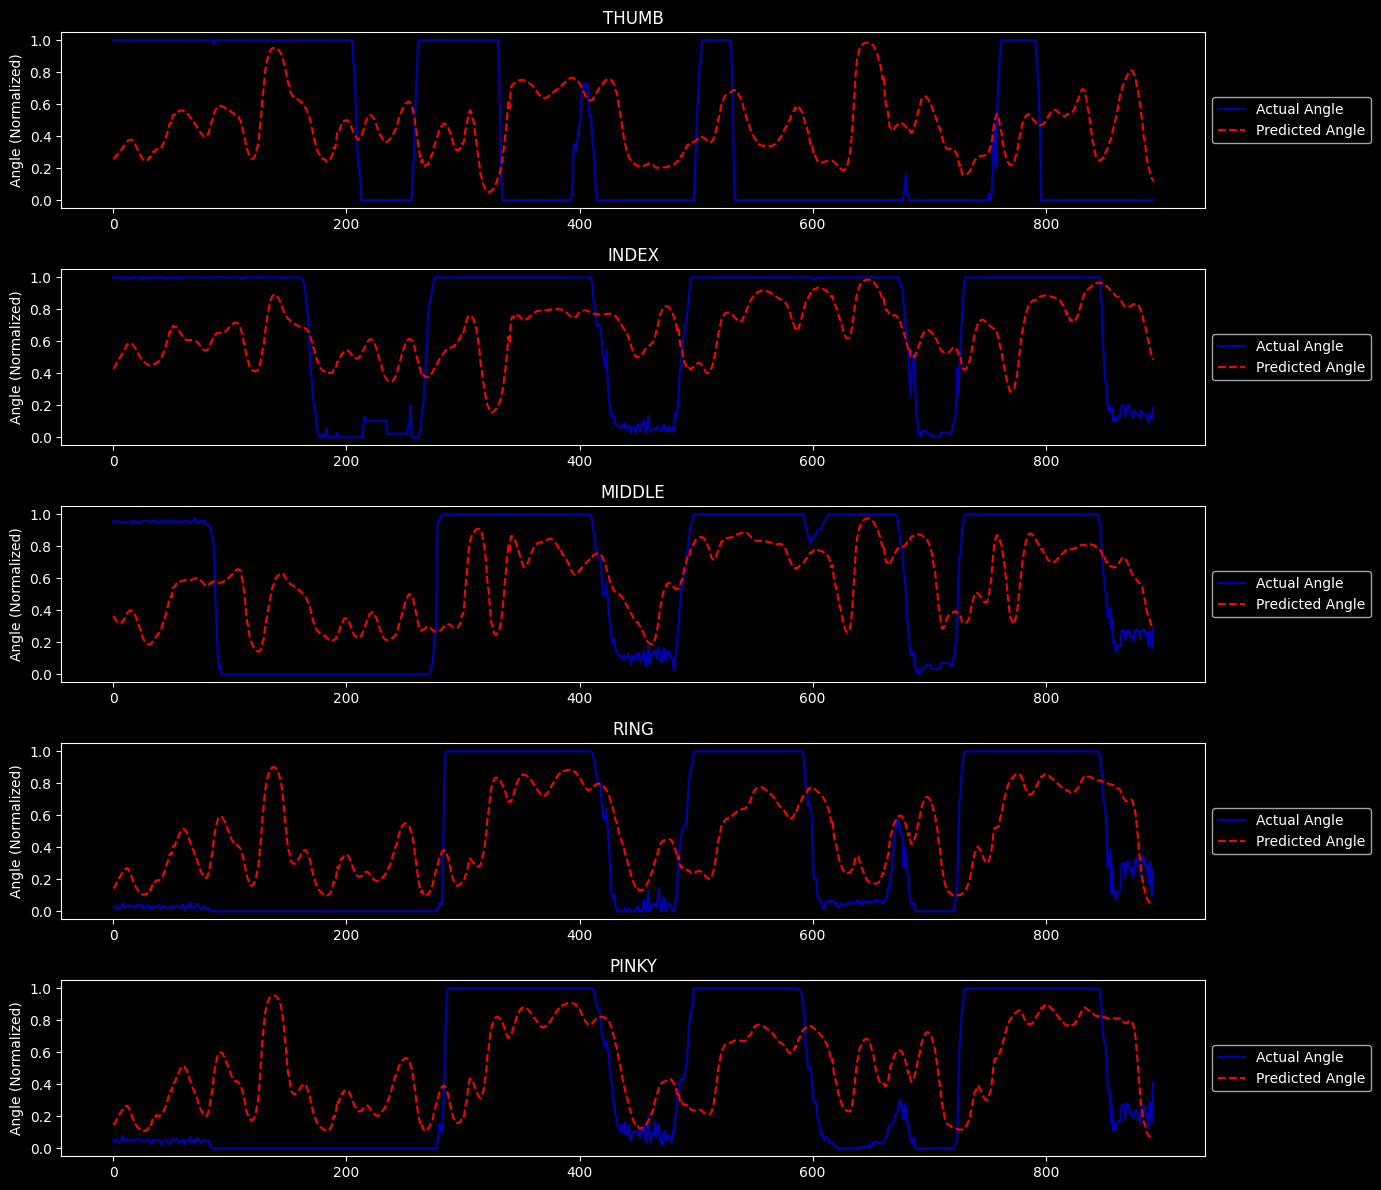

In [215]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred, n_samples=1000):
    """Plot the actual vs. predicted finger kinematics for visual verification."""
    finger_names = ['THUMB', 'INDEX', 'MIDDLE', 'RING', 'PINKY']
    num_fingers = y_true.shape[1]
    
    fig, axes = plt.subplots(num_fingers, 1, figsize=(14, 12))
    
    for i in range(num_fingers):
        axes[i].plot(y_true[:n_samples, i], color='blue', alpha=0.7, label='Actual Angle')
        axes[i].plot(y_pred[:n_samples, i], color='red', linestyle='--', label='Predicted Angle')
        axes[i].set_ylabel('Angle (Normalized)')
        axes[i].set_title(f'{finger_names[i]}')
        axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.tight_layout()
    plt.show()

# Example plot for all fingers
plot_predictions(y_test, y_pred)